In [1]:
 import numpy as np

In [2]:
arr = np.array([2,3,4,6,7,8,9,12,13,16,17,23,25,27,34,37,201])

In [3]:
arr

array([  2,   3,   4,   6,   7,   8,   9,  12,  13,  16,  17,  23,  25,
        27,  34,  37, 201])

In [6]:
Q1 = np.percentile(arr,25)
Q1

np.float64(7.0)

In [8]:
Q3 = np.percentile(arr,75)
Q3

np.float64(25.0)

In [9]:
IQR = Q3 - Q1
IQR

np.float64(18.0)

In [11]:
UF = Q3 + 1.5 * (IQR)
UF

np.float64(52.0)

In [12]:
LF = Q1 - 1.5 * (IQR)
LF

np.float64(-20.0)

In [15]:
l = []
for i in arr: 
    if i>= LF  and i<= UF:
        l.append(i)

In [18]:
arr2 = np.array(l)

In [19]:
arr2

array([ 2,  3,  4,  6,  7,  8,  9, 12, 13, 16, 17, 23, 25, 27, 34, 37])

In [21]:
arr

array([  2,   3,   4,   6,   7,   8,   9,  12,  13,  16,  17,  23,  25,
        27,  34,  37, 201])

In [22]:
import seaborn as sns

<Axes: >

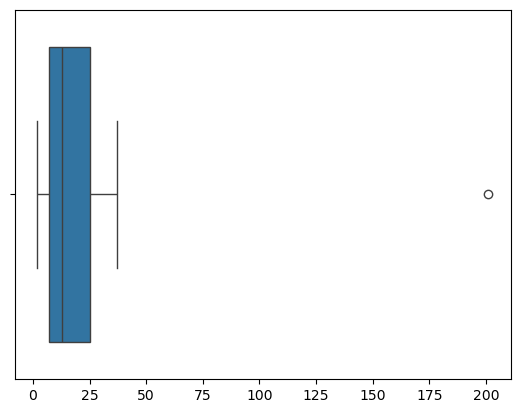

In [23]:
sns.boxplot(x = arr)

<Axes: >

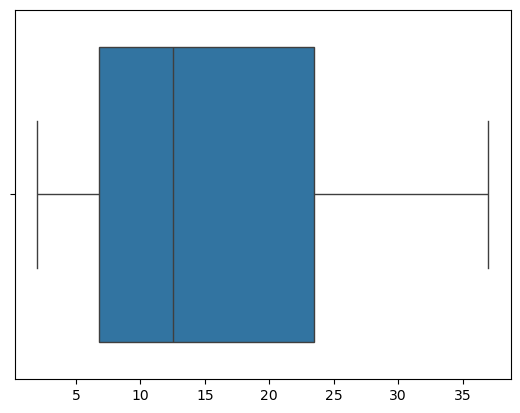

In [24]:
sns.boxplot(x = arr2)

In [50]:
import numpy as np 
from scipy.stats import norm

### Z test

In [37]:
sample = [172,174,168,171,173,175,170,169,172,172,174,168,171,173,175,170,169,172,172,174,168,171,173,175,170,169,172172,174,168,171,173,175,170,169,172] 
pop_mean = 170
pop_std = 3

In [38]:
sample_mean = np.mean(sample)
sample_mean

np.float64(5085.828571428571)

In [39]:
n = len(sample)
n

35

In [40]:
z_score = (sample_mean - pop_mean)/(pop_std/np.sqrt(n))
z_score

np.float64(9694.144676204012)

In [41]:
p_value = 2 * (1 - norm.cdf(abs(z_score)))
p_value

np.float64(0.0)

In [42]:
alpha = 0.05

In [43]:
if p_value < alpha: 
    print("I will reject the null hypothesis")
else:
    print("I will accept the null hypothesis")

I will reject the null hypothesis


### T test

**When we have unknown population STD we will use T test** 
**,Sample size is can be smaller than 30**

In [52]:
from scipy import stats
Sample = [172,174,168,171,173,175,170,169,172]
sample_mean = np.mean(sample)
sample_mean

np.float64(5085.828571428571)

In [53]:
sample_std = np.std(sample,ddof = 1) 
sample_std

np.float64(29073.385991806517)

In [54]:
n = len(sample)
n

35

In [55]:
mean_pop = 171
t_stats = (sample_mean - pop_mean)/(sample_std/np.sqrt(n))
t_stats

np.float64(1.0003112137268109)

In [57]:
p_values = 2 * (1 - stats.t.cdf(abs(t_stats),df = n - 1))
p_values

np.float64(0.32422631233344656)

In [58]:
alpha = 0.05

In [59]:
if p_value < alpha: 
    print("I will reject the null hypothesis")
else:
    print("I will accept the null hypothesis")

I will reject the null hypothesis


### Two Sample Test

In [60]:
group_A = [85,88,90,92,87,85,89,91,86,88]
group_B = [82,84,80,83,81,79,85,84,83]

In [64]:
t_stats, p_value = stats.ttest_ind(group_A,group_B,equal_var = False)
t_stats

np.float64(5.675945884099404)

In [65]:
alpha = 0.05

In [66]:
if p_value < alpha: 
    print("I will reject the null hypothesis")
else:
    print("I will accept the null hypothesis")

I will reject the null hypothesis


### Chi Square Test

In [67]:
import seaborn as sns 
from scipy.stats import chi2_contingency
import pandas as pd 

In [68]:
df = sns.load_dataset('titanic')

In [70]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [71]:
cont_table = pd.crosstab(df['sex'],df['survived'])
cont_table

survived,0,1
sex,,
female,81,233
male,468,109


In [77]:
chi2, p_value, dof, expected = chi2_contingency(cont_table)

In [78]:
expected

array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]])

In [79]:
dof

1

In [80]:
p_value

np.float64(1.1973570627755645e-58)

In [81]:
if p_value < alpha: 
    print("We reject the null hypothesis and there is a significtion relationship btw gender & survival")
else:
    print("There is no connection")

We reject the null hypothesis and there is a significtion relationship btw gender & survival


### Annova Test

In [83]:
from scipy.stats import f_oneway

In [86]:
df = sns.load_dataset('titanic')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [95]:
df = df[['age','pclass']].dropna()

In [96]:
df['pclass'].unique

<bound method Series.unique of 0      3
1      1
2      3
3      1
4      3
      ..
885    3
886    2
887    1
889    1
890    3
Name: pclass, Length: 714, dtype: int64>

In [97]:
class1 = df[df['pclass'] == 1]['age']
class1

1      38.0
3      35.0
6      54.0
11     58.0
23     28.0
       ... 
871    47.0
872    33.0
879    56.0
887    19.0
889    26.0
Name: age, Length: 186, dtype: float64

In [98]:
class2 = df[df['pclass'] == 2]['age']
class2

9      14.0
15     55.0
20     35.0
21     34.0
33     66.0
       ... 
866    27.0
874    28.0
880    25.0
883    28.0
886    27.0
Name: age, Length: 173, dtype: float64

In [99]:
class3 = df[df['pclass'] == 3]['age']
class3

0      22.0
2      26.0
4      35.0
7       2.0
8      27.0
       ... 
881    33.0
882    22.0
884    25.0
885    39.0
890    32.0
Name: age, Length: 355, dtype: float64

In [100]:
t_stats, p_value = f_oneway(class1,class2,class3)

In [101]:
p_value

np.float64(7.487984171959904e-24)

In [102]:
alpha = 0.05

In [103]:
if p_value < alpha: 
    print("Reject the null hypothesis & there is a significant difference in atleast one passenger class")
else:
    print("There is no siginificant difference")

Reject the null hypothesis & there is a significant difference in atleast one passenger class
